# QMF Final Exam — Part B
## The Counterfactual
### Blanchard–Quah Structural VAR approach

**Identification strategy.**  
Following Bayoumi & Eichengreen (1993) approach, this project estimates a bivariate SVAR on output and inflation for Ukraine and the Euro Area.
Importantly, I impose the Blanchard–Quah (1989) long-run restriction that demand shocks have no long-run effect on output. 
The counterfactual here is constructed by maintaining Ukraine's own supply shocks which are driven by factors such as energy prices and geopolitical events, while replacing Ukraine's demand shocks with the Euro Area's demand shocks. Thereby reflecting ECB monetary policy and EA aggregate demand. This is because joining the Euro Area removes monetary policy sovereignty so demand conditions would have been set by the ECB and not by the NBU


**Relation to Part A.**  
As indicated in part A, during peg periods Ukraine's monetary policy was focused on maintaining the exchange rate. Thus, the treatment effect of joining the Euro Area is smaller in these periods and larger in periods where Ukraine had genuine monetary policy sovereignty. 

The FX rate (UAH/USD) is intentionally excluded in the counterfactual exogenous block as the hryvnia would not exist under Euro Area membership.

LOADING RAW FILES
  ECB HICP: (312, 13)
  Ukraine CPI: (312, 4)
  Ukraine IP: (289, 4)
  EA IP: (356, 3)
  USD FX: (312, 4)
  EUR FX: (312, 4)
  NBU rate: (316, 2)
  ECB refi: (324, 2)
  CMO: (794, 5)

AUGMENTED DICKEY-FULLER STATIONARITY TESTS  (H0: unit root)
Variable                 ADF stat    p-value   Stationary 5%
--------------------------------------------------------------
  UKR_IP_YOY               -3.516     0.0076             YES
  UKR_CPI_YOY              -4.310     0.0004             YES
  EA_IP_YOY                -3.765     0.0033             YES
  EA_HICP_YOY              -2.132     0.2318   NO  <-- check

Note: YoY growth-rate series are typically stationary (I(0)).
The BQ long-run restriction is applied to the level VAR, consistent with Blanchard & Quah (1989) who use first-differenced log output and inflation which are both stationary transformations. 


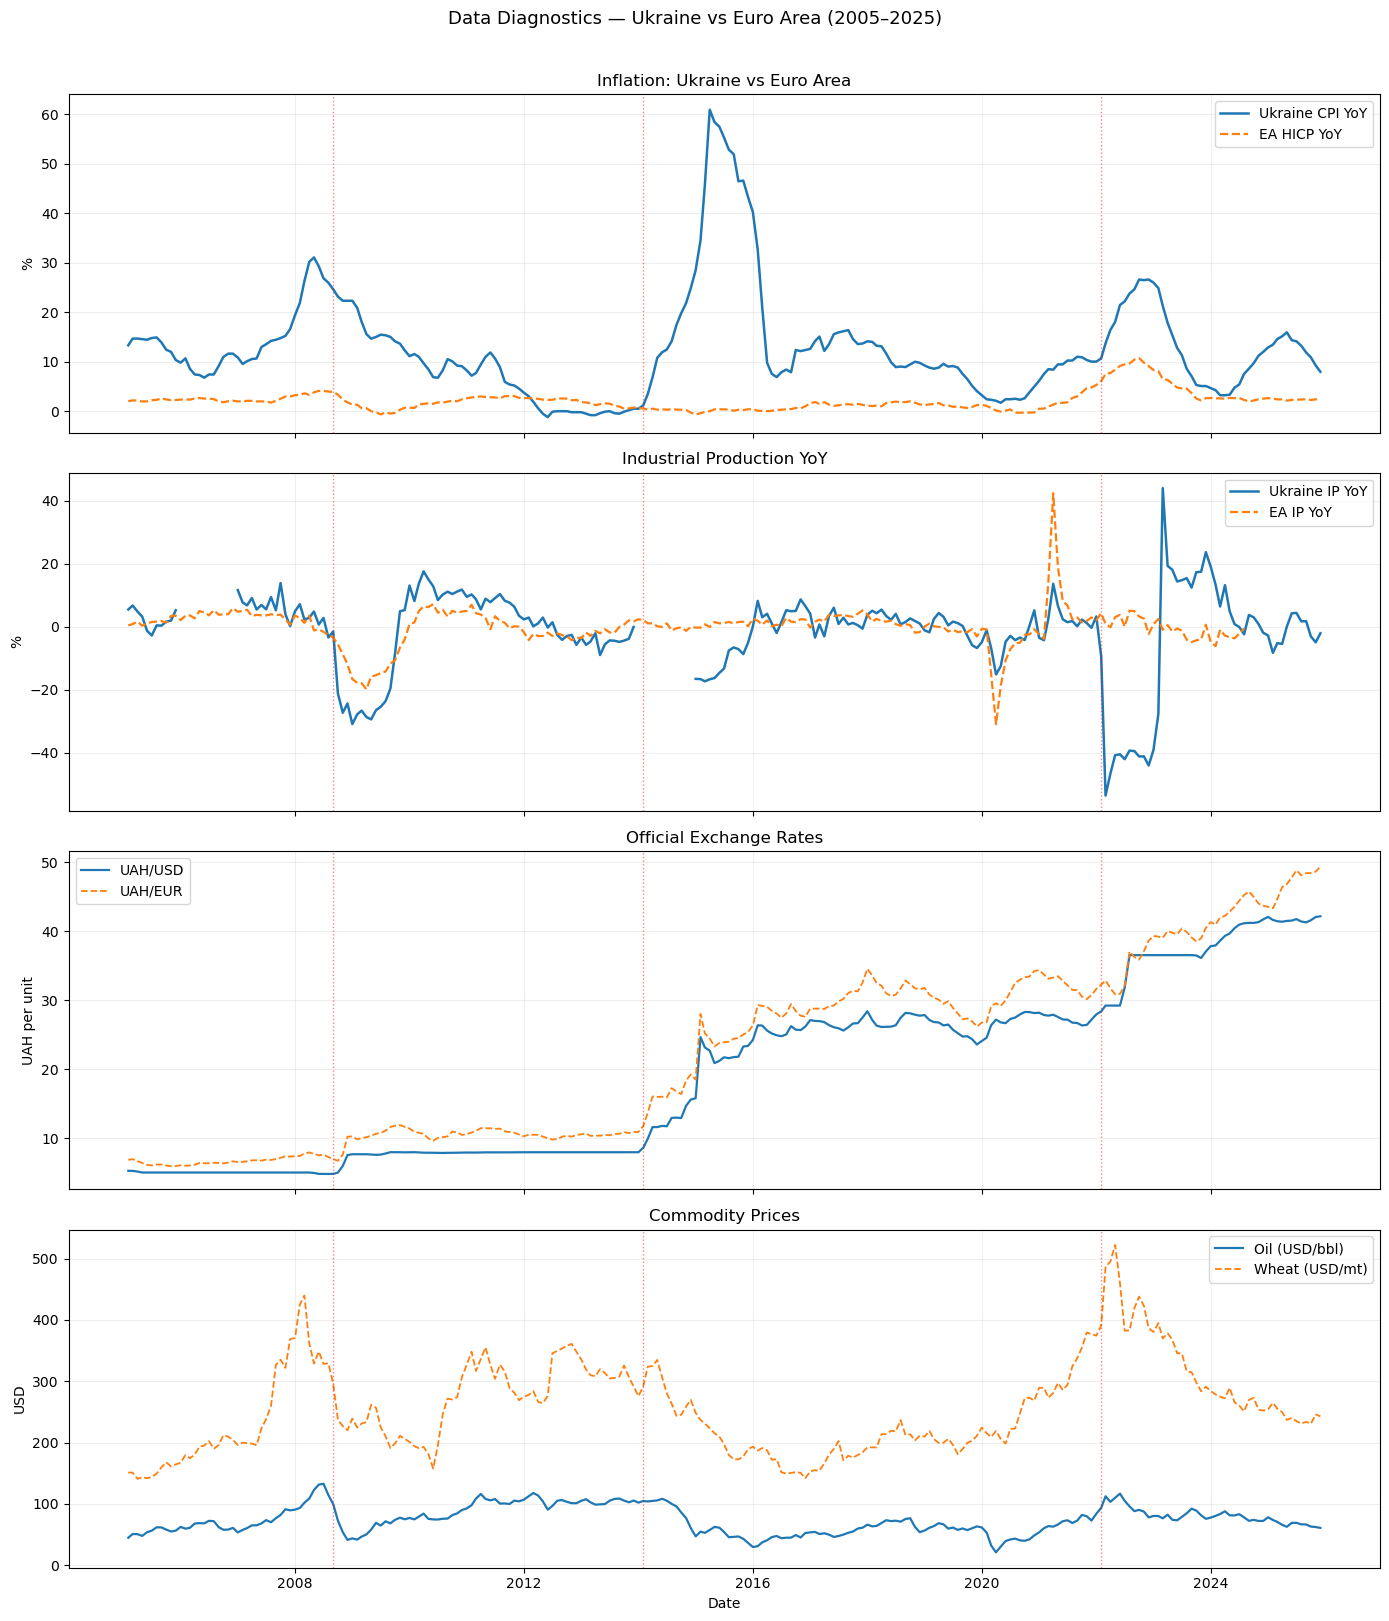


Outputs saved:
  /Users/evelyn/Desktop/M2/QMF2/data/analysis_dataset_monthly.csv
  /Users/evelyn/Desktop/M2/QMF2/data/bq_svar_inputs.csv
  /Users/evelyn/Desktop/M2/QMF2/data/data_diagnostics.png

Missing values in BQ inputs:
UKR_IP_YOY         24
UKR_CPI_YOY         0
EA_IP_YOY          16
EA_HICP_YOY         0
dlog_uah_usd        0
dlog_uah_eur        0
dlog_oil            0
dlog_wheat          0
NBU_POLICY_RATE     0
ECB_REFI_RATE       0
CRISIS_0809         0
CRISIS_1415         0
WAR_2022PLUS        0
POST_2016_IT        0

Ukraine CPI YoY peaks:
  2008-09 peak = 31.06
  2014-16 peak = 60.91
  2022-23 peak = 26.60


In [ ]:
import os
import json
import warnings
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller


warnings.filterwarnings("ignore")

# ── Path ─────
ROOT_DIR = Path.cwd()
while not (ROOT_DIR / "data").exists() and ROOT_DIR != ROOT_DIR.parent:
    ROOT_DIR = ROOT_DIR.parent

DATA_DIR = ROOT_DIR / "data"

if not DATA_DIR.exists():
    raise FileNotFoundError("No data/ folder found in this repository.")

# Raw input files
PATH_ECB_HICP  = DATA_DIR / "data_ecb_hicp_panel.csv"
PATH_UKR_CPI   = DATA_DIR / "data_ukraine_cpi_raw.csv"
PATH_UKR_IP    = DATA_DIR / "ukraine_industrial_production_index_2002_2026.csv"
PATH_EA_IP     = DATA_DIR / "Euro_area_industrial.csv"
PATH_USD       = DATA_DIR / "usd_nbu.json"
PATH_EUR       = DATA_DIR / "eur_nbu.json"
PATH_NBU       = DATA_DIR / "NBU_monetary_operations_with_banks_interest_rates.csv"
PATH_ECB_REFI  = DATA_DIR / "ECB_refinance.csv"
PATH_CMO       = DATA_DIR / "CMO-Historical-Data-Monthly.xlsx"

required_files = [
    PATH_ECB_HICP,
    PATH_UKR_CPI,
    PATH_UKR_IP,
    PATH_EA_IP,
    PATH_USD,
    PATH_EUR,
    PATH_NBU,
    PATH_ECB_REFI,
    PATH_CMO,
]

missing_files = [p.name for p in required_files if not p.exists()]
if missing_files:
    raise FileNotFoundError(
        "Missing required files in data/: " + ", ".join(missing_files)
    )

OUT_DIR = ROOT_DIR / "output"
OUT_DIR.mkdir(exist_ok=True)

# Generated outputs
OUT_ANALYSIS = OUT_DIR / "analysis_dataset_monthly.csv"
OUT_BQ       = OUT_DIR / "bq_svar_inputs.csv"
OUT_DIAG     = OUT_DIR / "data_diagnostics.png"

SAMPLE_START = "2005-02-01"
SAMPLE_END   = "2025-12-01"

EA_COUNTRIES = ["AT", "BE", "DE", "ES", "FI", "FR", "GR", "IE", "IT", "NL", "PT"]

# ── Helpers ──

def month_start(series):
    return pd.to_datetime(series).dt.to_period("M").dt.to_timestamp()

def parse_ukr_time_period(series):
    return pd.to_datetime(
        series.astype(str).str.replace("-M", "-", regex=False), format="%Y-%m"
    )

def compute_yoy_from_level(level):
    return 100.0 * (level / level.shift(12) - 1.0)

def safe_numeric(s):
    return pd.to_numeric(s, errors="coerce")


# ── Loaders ─────

def load_ecb_hicp(path):
    df = pd.read_csv(path)
    df["date"] = pd.to_datetime(df["TIME_PERIOD"])
    for c in EA_COUNTRIES:
        df[c] = safe_numeric(df[c])
    df["EA_HICP_YOY"] = df[EA_COUNTRIES].mean(axis=1)
    return df[["date"] + EA_COUNTRIES + ["EA_HICP_YOY"]].sort_values("date").reset_index(drop=True)

def load_ukraine_cpi(path):
    raw = pd.read_csv(path)
    df  = raw[["TIME_PERIOD", "OBS_VALUE"]].copy()
    df["date"]              = parse_ukr_time_period(df["TIME_PERIOD"])
    df["UKR_CPI_MOM_INDEX"] = safe_numeric(df["OBS_VALUE"])
    df = df.sort_values("date").reset_index(drop=True)
    df["monthly_factor"]    = df["UKR_CPI_MOM_INDEX"] / 100.0
    df["UKR_CPI_LEVEL"]     = 100.0 * df["monthly_factor"].cumprod()
    df["UKR_CPI_YOY"]       = compute_yoy_from_level(df["UKR_CPI_LEVEL"])
    return df[["date", "UKR_CPI_MOM_INDEX", "UKR_CPI_LEVEL", "UKR_CPI_YOY"]]

def load_ukraine_ip(path):
    df = pd.read_csv(path)
    required = ["date", "industrial_production_index", "base_label"]
    missing  = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Ukraine IP csv missing columns: {missing}")
    df["date"]        = pd.to_datetime(df["date"])
    df["UKR_IP_LEVEL"] = safe_numeric(df["industrial_production_index"])
    df["base_label"]  = df["base_label"].astype(str)
    pieces = []
    for _, g in df.sort_values("date").groupby("base_label"):
        g = g.copy()
        g["UKR_IP_YOY"] = compute_yoy_from_level(g["UKR_IP_LEVEL"])
        pieces.append(g)
    out = pd.concat(pieces).sort_values("date").reset_index(drop=True)
    return out[["date", "UKR_IP_LEVEL", "UKR_IP_YOY", "base_label"]]

def load_ea_ip(path):
    df        = pd.read_csv(path)
    value_col = [c for c in df.columns if c not in ["DATE", "TIME PERIOD", "TIME_PERIOD"]][0]
    df["date"]       = month_start(pd.to_datetime(df["DATE"], errors="coerce"))
    df["EA_IP_LEVEL"] = safe_numeric(df[value_col])
    df = df.sort_values("date").reset_index(drop=True)
    df["EA_IP_YOY"]  = compute_yoy_from_level(df["EA_IP_LEVEL"])
    return df[["date", "EA_IP_LEVEL", "EA_IP_YOY"]]

def load_nbu_fx(path, out_name):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    df = pd.DataFrame(data)
    df["date"] = pd.to_datetime(df["exchangedate"], format="%d.%m.%Y", errors="coerce")
    df["value"] = safe_numeric(df["rate_per_unit"] if "rate_per_unit" in df.columns else df["rate"])
    df["month"] = df["date"].dt.to_period("M").dt.to_timestamp()
    monthly = (
        df.groupby("month", as_index=False)["value"]
        .mean()
        .rename(columns={"month": "date", "value": out_name})
    )
    monthly[f"log_{out_name.lower()}"] = np.log(monthly[out_name])
    monthly[f"dlog_{out_name.lower()}"] = monthly[f"log_{out_name.lower()}"].diff()
    return monthly

def load_nbu_rate(path):
    df = pd.read_csv(path)
    df.columns = ["date", "NBU_POLICY_RATE", "lending_facility", "deposit_facility"]
    df["date"] = pd.to_datetime(df["date"], format="%d.%m.%Y", errors="coerce")
    df["NBU_POLICY_RATE"] = safe_numeric(df["NBU_POLICY_RATE"])
    df = df[["date", "NBU_POLICY_RATE"]].dropna().sort_values("date")
    df["date"] = df["date"].dt.to_period("M").dt.to_timestamp()
    return df.groupby("date", as_index=False)["NBU_POLICY_RATE"].mean()

def load_ecb_refi(path):
    df = pd.read_csv(path)
    df["date"]         = pd.to_datetime(df["DATE"], errors="coerce").dt.to_period("M").dt.to_timestamp()
    df["ECB_REFI_RATE"] = pd.to_numeric(df[df.columns[-1]], errors="coerce")
    df = df[["date", "ECB_REFI_RATE"]].dropna().sort_values("date")
    df = df.groupby("date", as_index=False)["ECB_REFI_RATE"].last()
    idx = pd.DataFrame({"date": pd.date_range(df["date"].min(), pd.Timestamp(SAMPLE_END), freq="MS")})
    out = idx.merge(df, on="date", how="left")
    out["ECB_REFI_RATE"] = out["ECB_REFI_RATE"].ffill()
    return out

def load_cmo(path):
    raw  = pd.read_excel(path, sheet_name="Monthly Prices", header=None)
    hdr  = raw.iloc[4].tolist()
    df   = raw.iloc[6:].copy()
    df.columns = ["period"] + hdr[1:]
    keep = ["period", "Crude oil, average", "Wheat, US HRW"]
    missing = [c for c in keep if c not in df.columns]
    if missing:
        raise ValueError(f"Commodity file missing: {missing}")
    df = df[keep].copy()
    df["date"]        = pd.to_datetime(df["period"].astype(str), format="%YM%m", errors="coerce")
    df["OIL_PRICE"]   = safe_numeric(df["Crude oil, average"])
    df["WHEAT_PRICE"] = safe_numeric(df["Wheat, US HRW"])
    df = df[["date", "OIL_PRICE", "WHEAT_PRICE"]].dropna(subset=["date"]).sort_values("date")
    df["dlog_oil"]   = np.log(df["OIL_PRICE"]).diff()
    df["dlog_wheat"] = np.log(df["WHEAT_PRICE"]).diff()
    return df

def add_dummies(df):
    out = df.copy()
    out["CRISIS_0809"]  = ((out["date"] >= "2008-09-01") & (out["date"] <= "2009-12-01")).astype(int)
    out["CRISIS_1415"]  = ((out["date"] >= "2014-02-01") & (out["date"] <= "2015-12-01")).astype(int)
    out["WAR_2022PLUS"] = (out["date"] >= "2022-02-01").astype(int)
    out["POST_2016_IT"] = (out["date"] >= "2016-01-01").astype(int)
    return out

# ── Load & merge ───
print("=" * 70)
print("LOADING RAW FILES")
print("=" * 70)

ecb_hicp  = load_ecb_hicp(PATH_ECB_HICP)
ukr_cpi   = load_ukraine_cpi(PATH_UKR_CPI)
ukr_ip    = load_ukraine_ip(PATH_UKR_IP)
ea_ip     = load_ea_ip(PATH_EA_IP)
usd       = load_nbu_fx(PATH_USD, "UAH_USD")
eur       = load_nbu_fx(PATH_EUR, "UAH_EUR")
nbu       = load_nbu_rate(PATH_NBU)
ecb_refi  = load_ecb_refi(PATH_ECB_REFI)
cmo       = load_cmo(PATH_CMO)

for name, df_ in [("ECB HICP", ecb_hicp), ("Ukraine CPI", ukr_cpi),
                   ("Ukraine IP", ukr_ip),  ("EA IP", ea_ip),
                   ("USD FX", usd),         ("EUR FX", eur),
                   ("NBU rate", nbu),       ("ECB refi", ecb_refi),
                   ("CMO", cmo)]:
    print(f"  {name}: {df_.shape}")

backbone  = pd.DataFrame({"date": pd.date_range(SAMPLE_START, SAMPLE_END, freq="MS")})
analysis  = backbone.copy()
for df_ in [ukr_cpi, ecb_hicp, ukr_ip, ea_ip, usd, eur, nbu, ecb_refi, cmo]:
    analysis = analysis.merge(df_, on="date", how="left")
analysis = add_dummies(analysis).sort_values("date").reset_index(drop=True)

# ── BQ input dataset ────
bq_cols = [
    "date",
    "UKR_IP_YOY", "UKR_CPI_YOY",
    "EA_IP_YOY",  "EA_HICP_YOY",
    "dlog_uah_usd", "dlog_uah_eur",
    "dlog_oil", "dlog_wheat",
    "NBU_POLICY_RATE", "ECB_REFI_RATE",
    "CRISIS_0809", "CRISIS_1415", "WAR_2022PLUS", "POST_2016_IT",
]
bq = analysis[bq_cols].copy()
bq_est = bq.dropna(subset=["UKR_IP_YOY", "UKR_CPI_YOY", "EA_IP_YOY", "EA_HICP_YOY"]).copy()

# ── Stationarity tests ────────
print("\n" + "=" * 70)
print("AUGMENTED DICKEY-FULLER STATIONARITY TESTS  (H0: unit root)")
print("=" * 70)
print(f"{'Variable':<22} {'ADF stat':>10} {'p-value':>10} {'Stationary 5%':>15}")
print("-" * 62)
for col in ["UKR_IP_YOY", "UKR_CPI_YOY", "EA_IP_YOY", "EA_HICP_YOY"]:
    s = bq_est[col].dropna()
    stat, pval, *_ = adfuller(s, autolag="AIC")
    flag = "YES" if pval < 0.05 else "NO  <-- check"
    print(f"  {col:<20} {stat:>10.3f} {pval:>10.4f} {flag:>15}")
print()
print("Note: YoY growth-rate series are typically stationary (I(0)).")
print("The BQ long-run restriction is applied to the level VAR, consistent with Blanchard & Quah (1989) who use first-differenced log output and inflation which are both stationary transformations. ")

# ── Diagnostics plot ───────────
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

axes[0].plot(analysis["date"], analysis["UKR_CPI_YOY"],  label="Ukraine CPI YoY",  lw=1.8)
axes[0].plot(analysis["date"], analysis["EA_HICP_YOY"],  label="EA HICP YoY",      lw=1.6, ls="--")
axes[0].set_title("Inflation: Ukraine vs Euro Area"); axes[0].set_ylabel("%"); axes[0].legend()

axes[1].plot(analysis["date"], analysis["UKR_IP_YOY"],   label="Ukraine IP YoY",   lw=1.8)
axes[1].plot(analysis["date"], analysis["EA_IP_YOY"],    label="EA IP YoY",        lw=1.6, ls="--")
axes[1].set_title("Industrial Production YoY"); axes[1].set_ylabel("%"); axes[1].legend()

axes[2].plot(analysis["date"], analysis["UAH_USD"],      label="UAH/USD",          lw=1.6)
axes[2].plot(analysis["date"], analysis["UAH_EUR"],      label="UAH/EUR",          lw=1.3, ls="--")
axes[2].set_title("Official Exchange Rates"); axes[2].set_ylabel("UAH per unit"); axes[2].legend()

axes[3].plot(analysis["date"], analysis["OIL_PRICE"],    label="Oil (USD/bbl)",    lw=1.6)
axes[3].plot(analysis["date"], analysis["WHEAT_PRICE"],  label="Wheat (USD/mt)",   lw=1.3, ls="--")
axes[3].set_title("Commodity Prices"); axes[3].set_ylabel("USD"); axes[3].legend()

for ax in axes:
    for d in ["2008-09-01", "2014-02-01", "2022-02-01"]:
        ax.axvline(pd.Timestamp(d), color="red", ls=":", alpha=0.5, lw=1)
    ax.grid(alpha=0.2)
axes[3].set_xlabel("Date")

plt.suptitle("Data Diagnostics — Ukraine vs Euro Area (2005–2025)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIAG, dpi=150, bbox_inches="tight")
plt.show()

analysis.to_csv(OUT_ANALYSIS, index=False)
bq_est.to_csv(OUT_BQ, index=False)

print("\nOutputs saved:")
print(f"  {OUT_ANALYSIS}")
print(f"  {OUT_BQ}")
print(f"  {OUT_DIAG}")
print("\nMissing values in BQ inputs:")
print(bq[bq_cols[1:]].isna().sum().to_string())
print("\nUkraine CPI YoY peaks:")
for start, end, label in [("2008-01-01","2009-12-01","2008-09"),
                            ("2014-01-01","2016-12-01","2014-16"),
                            ("2022-01-01","2023-12-01","2022-23")]:
    sub = analysis.loc[(analysis["date"]>=start)&(analysis["date"]<=end), "UKR_CPI_YOY"]
    print(f"  {label} peak = {sub.max():.2f}" if sub.notna().any() else f"  {label} peak = n/a")


MODEL SAMPLE
  Start : 2005-02-01
  End   : 2024-08-01
  Rows  : 211

Lag selection (AIC):  Ukraine = 5   EA = 11

Ukraine VAR: 5 lags, sigma_u diag = [53.972  6.008]
EA VAR:      11 lags,  sigma_u diag = [10.655  0.088]

Simulating counterfactual...
Counterfactual sample: 2007-01-01 – 2024-08-01
Observations: 200


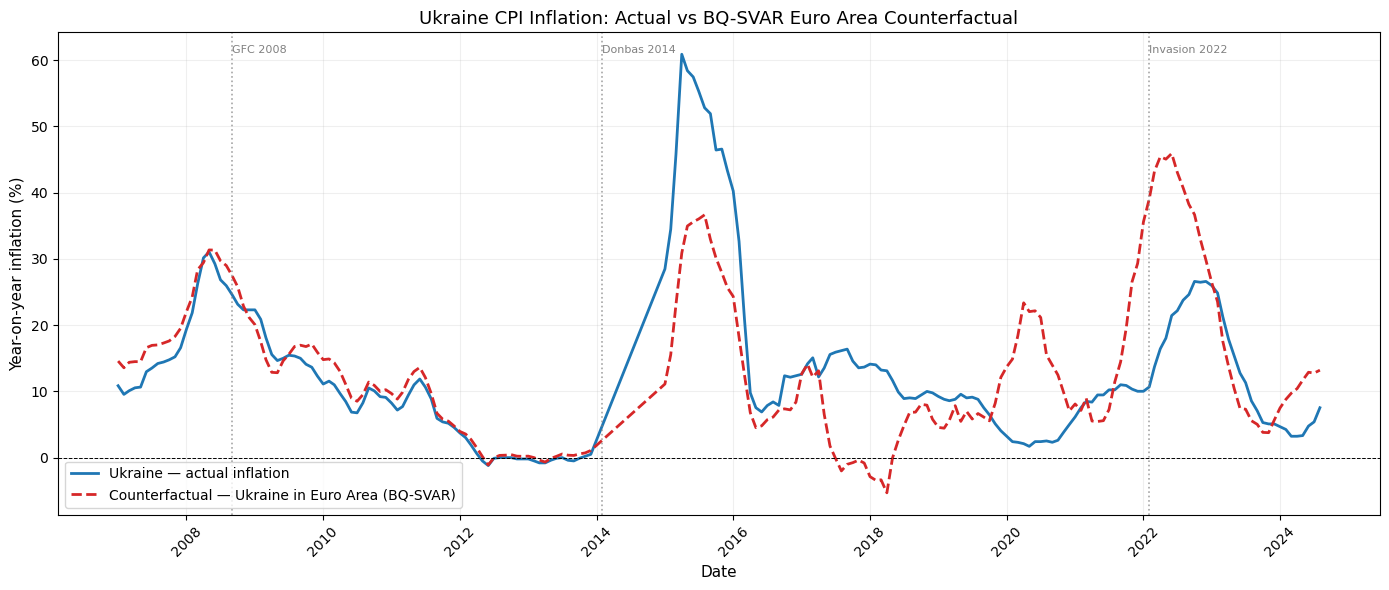

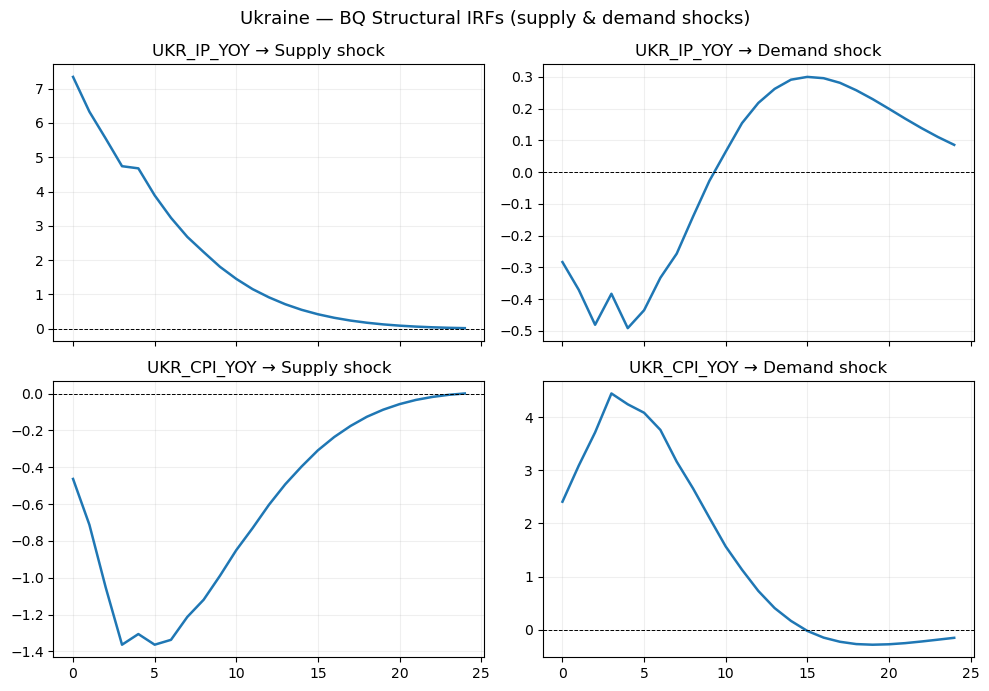

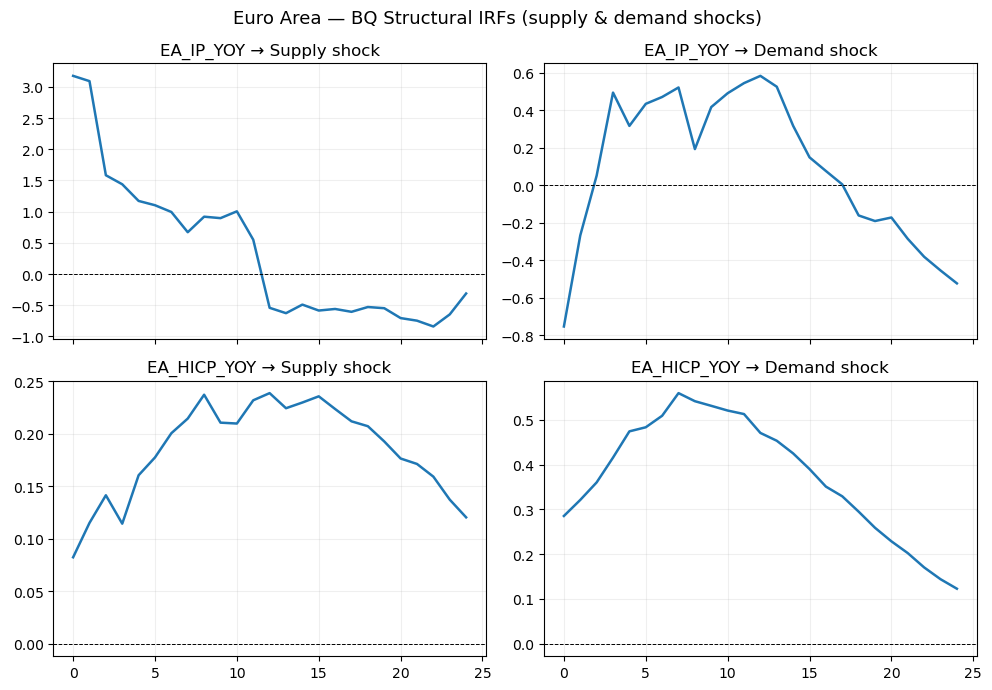


QUICK SUMMARY
  Avg actual inflation       : 13.03%
  Avg counterfactual         : 13.13%
  Avg gap (actual − CF)      : -0.11 pp

  Crisis         Actual peak    CF peak      Gap
  ----------------------------------------------
  2008-09              31.06      31.36    -0.30
  2014-15              60.91      36.66   +24.25
  2022-23              26.60      45.92   -19.32

Saved: /Users/evelyn/Desktop/M2/QMF2/data/bq_counterfactual_series.csv
       /Users/evelyn/Desktop/M2/QMF2/data/bq_counterfactual_plot.png
       /Users/evelyn/Desktop/M2/QMF2/data/bq_irfs_ukraine.png
       /Users/evelyn/Desktop/M2/QMF2/data/bq_irfs_ea.png
       /Users/evelyn/Desktop/M2/QMF2/data/bq_summary.txt


In [ ]:
import matplotlib.dates as mdates
from statsmodels.tsa.vector_ar.var_model import VAR
import sys

SRC_DIR = ROOT_DIR / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))
    


from model_utils import (
    choose_lag,
    long_run_multiplier,
    bq_impact_matrix,
    get_structural_shocks,
    monetary_autonomy_weight,
    simulate_counterfactual,
)

# ── Paths ───

PATH_IN          = OUT_DIR / "bq_svar_inputs.csv"
PATH_OUT_SERIES  = OUT_DIR / "bq_counterfactual_series.csv"
PATH_OUT_FIG     = OUT_DIR / "bq_counterfactual_plot.png"
PATH_OUT_IRF_UKR = OUT_DIR / "bq_irfs_ukraine.png"
PATH_OUT_IRF_EA  = OUT_DIR / "bq_irfs_ea.png"
PATH_OUT_SUMMARY = OUT_DIR / "bq_summary.txt"

# ── Model settings ────
UKR_ENDOG   = ["UKR_IP_YOY", "UKR_CPI_YOY"]
EA_ENDOG    = ["EA_IP_YOY",  "EA_HICP_YOY"]

# I include oil and wheat price changes as exogenous controls in the VAR, since they are important global factors 
# that affect both Ukraine and the Euro Area, and would still impact Ukraine even if it were an EA member.
EXOG_COLS   = ["dlog_oil", "dlog_wheat"]

MAX_LAGS    = 12
LAG_IC      = "aic"
IRF_HORIZON = 24
CRISIS_DATES = ["2008-09-01", "2014-02-01", "2022-02-01"]


def make_irf_plot(results, B, title, out_path, horizon=24):
    """Plot 2×2 structural IRF grid."""
    irf    = results.irf(horizon)
    ma     = irf.irfs                          # (h+1, k, k) reduced-form
    s_irf  = np.einsum("hij,jk->hik", ma, B)  # structural

    fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)
    shock_names = ["Supply shock", "Demand shock"]
    var_names   = results.names
    for i in range(2):
        for j in range(2):
            ax = axes[i, j]
            ax.plot(range(horizon + 1), s_irf[:, i, j], lw=1.8)
            ax.axhline(0, color="black", ls="--", lw=0.7)
            ax.set_title(f"{var_names[i]} → {shock_names[j]}")
            ax.grid(alpha=0.2)
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

# ── Load data ──
if not PATH_IN.exists():
    raise FileNotFoundError(
        f"Missing input file: {PATH_IN}. Run the dataset-building cell first."
    )
df = pd.read_csv(PATH_IN, parse_dates=["date"]).sort_values("date").reset_index(drop=True)

needed    = UKR_ENDOG + EA_ENDOG + EXOG_COLS
model_df  = (df[["date"] + needed]
             .dropna()
             .drop_duplicates(subset="date")
             .set_index("date")
             .sort_index())

print("=" * 70)
print("MODEL SAMPLE")
print("=" * 70)
print(f"  Start : {model_df.index.min().date()}")
print(f"  End   : {model_df.index.max().date()}")
print(f"  Rows  : {len(model_df)}")

# ── Lag selection ──
ukr_endog = model_df[UKR_ENDOG].copy()
ea_endog  = model_df[EA_ENDOG].copy()
exog      = model_df[EXOG_COLS].copy()

p_ukr = choose_lag(ukr_endog, exog, MAX_LAGS, LAG_IC)
p_ea  = choose_lag(ea_endog,  exog, MAX_LAGS, LAG_IC)

print(f"\nLag selection ({LAG_IC.upper()}):  Ukraine = {p_ukr}   EA = {p_ea}")

# ── Estimate reduced-form VARs ──
ukr_res = VAR(endog=ukr_endog, exog=exog).fit(maxlags=p_ukr, trend="c")
ea_res  = VAR(endog=ea_endog,  exog=exog).fit(maxlags=p_ea,  trend="c")

print(f"\nUkraine VAR: {ukr_res.k_ar} lags, sigma_u diag = "
      f"{np.diag(ukr_res.sigma_u.values).round(3)}")
print(f"EA VAR:      {ea_res.k_ar} lags,  sigma_u diag = "
      f"{np.diag(ea_res.sigma_u.values).round(3)}")

# ── BQ identification ───
B_ukr      = bq_impact_matrix(ukr_res.coefs, ukr_res.sigma_u.values)
B_ea       = bq_impact_matrix(ea_res.coefs,  ea_res.sigma_u.values)

ea_shocks  = get_structural_shocks(ea_res.resid, B_ea)

# ── Counterfactual simulation ───
print("\nSimulating counterfactual...")
y_cf_df = simulate_counterfactual(ukr_res, B_ukr, ea_shocks, UKR_ENDOG)

# Align with actual series on common index
common_idx  = y_cf_df.index.intersection(
    pd.to_datetime(ukr_res.fittedvalues.index).drop_duplicates())
y_actual    = model_df.loc[common_idx, UKR_ENDOG].copy()
y_cf_df     = y_cf_df.loc[common_idx].copy()

print(f"Counterfactual sample: {y_cf_df.index.min().date()} – {y_cf_df.index.max().date()}")
print(f"Observations: {len(y_cf_df)}")

# ── Save series ──
out = pd.DataFrame({
    "date":                      y_actual.index,
    "ukr_ip_yoy_actual":         y_actual["UKR_IP_YOY"].values,
    "ukr_cpi_yoy_actual":        y_actual["UKR_CPI_YOY"].values,
    "ukr_ip_yoy_counterfactual": y_cf_df["UKR_IP_YOY"].values,
    "ukr_cpi_yoy_counterfactual":y_cf_df["UKR_CPI_YOY"].values,
})
out["inflation_gap_actual_minus_cf"] = (
    out["ukr_cpi_yoy_actual"] - out["ukr_cpi_yoy_counterfactual"])
out.to_csv(PATH_OUT_SERIES, index=False)

# ── Main figure ───
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(out["date"], out["ukr_cpi_yoy_actual"],
        label="Ukraine — actual inflation", lw=2.0, color="#1f77b4")
ax.plot(out["date"], out["ukr_cpi_yoy_counterfactual"],
        label="Counterfactual — Ukraine in Euro Area (BQ-SVAR)",
        lw=2.0, ls="--", color="#d62728")

for d, lbl in zip(CRISIS_DATES, ["GFC 2008", "Donbas 2014", "Invasion 2022"]):
    ax.axvline(pd.Timestamp(d), color="grey", ls=":", alpha=0.7, lw=1.2)
    ax.text(pd.Timestamp(d), ax.get_ylim()[1]*0.97 if ax.get_ylim()[1]>0 else 5,
            lbl, fontsize=8, color="grey", ha="left", va="top")

ax.axhline(0, color="black", ls="--", lw=0.7)
ax.set_title("Ukraine CPI Inflation: Actual vs BQ-SVAR Euro Area Counterfactual",
             fontsize=13)
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Year-on-year inflation (%)", fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
plt.xticks(rotation=45)
ax.legend(fontsize=10)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(PATH_OUT_FIG, dpi=150, bbox_inches="tight")
plt.show()

# ── IRFs ──
make_irf_plot(ukr_res, B_ukr,
              "Ukraine — BQ Structural IRFs (supply & demand shocks)",
              PATH_OUT_IRF_UKR, IRF_HORIZON)
make_irf_plot(ea_res,  B_ea,
              "Euro Area — BQ Structural IRFs (supply & demand shocks)",
              PATH_OUT_IRF_EA,  IRF_HORIZON)

# ── Summary stats ───
print("\n" + "=" * 70)
print("QUICK SUMMARY")
print("=" * 70)
avg_act = out["ukr_cpi_yoy_actual"].mean()
avg_cf  = out["ukr_cpi_yoy_counterfactual"].mean()
print(f"  Avg actual inflation       : {avg_act:.2f}%")
print(f"  Avg counterfactual         : {avg_cf:.2f}%")
print(f"  Avg gap (actual − CF)      : {avg_act - avg_cf:.2f} pp")
print()
print(f"  {'Crisis':<12} {'Actual peak':>13} {'CF peak':>10} {'Gap':>8}")
print("  " + "-" * 46)
for start, end, label in [("2008-01-01","2009-12-01","2008-09"),
                            ("2014-01-01","2015-12-01","2014-15"),
                            ("2022-01-01","2023-12-01","2022-23")]:
    sub = out[(out["date"] >= start) & (out["date"] <= end)]
    if len(sub):
        ap = sub["ukr_cpi_yoy_actual"].max()
        cp = sub["ukr_cpi_yoy_counterfactual"].max()
        print(f"  {label:<12} {ap:>13.2f} {cp:>10.2f} {ap-cp:>+8.2f}")

# Summary
lines = [
    "Counterfactual findings",
    "=" * 60,
    f"Model sample: {model_df.index.min().date()} to {model_df.index.max().date()}",
    f"Observations: {len(model_df)}",
    "",
    f"Ukraine lag order ({LAG_IC}): {p_ukr}",
    f"EA lag order ({LAG_IC}):      {p_ea}",
    "",
    "Endogenous — Ukraine : " + str(UKR_ENDOG),
    "Endogenous — EA      : " + str(EA_ENDOG),
    "Exogenous controls   : " + str(EXOG_COLS),
    "",
    "BQ identification:",
    "  Shock 1 = supply",
    "  Shock 2 = demand",
    "",
    "Counterfactual: keep Ukraine supply shocks,",
    "  replace Ukraine demand shocks with Euro Area demand shocks.",
    "  Full VAR re-simulation from initial conditions.",
]
with open(PATH_OUT_SUMMARY, "w", encoding="utf-8") as f:
    f.write("\n".join(lines))

print(f"\nSaved: {PATH_OUT_SERIES}")
print(f"       {PATH_OUT_FIG}")
print(f"       {PATH_OUT_IRF_UKR}")
print(f"       {PATH_OUT_IRF_EA}")
print(f"       {PATH_OUT_SUMMARY}")


ROBUSTNESS CHECKS
  OK  baseline_no_fx_aic              n=200  gap=-0.106 pp
  OK  baseline_no_fx_bic              n=207  gap=0.183 pp
  OK  baseline_no_fx_lag6             n=205  gap=0.082 pp
  OK  baseline_no_fx_lag12            n=199  gap=0.116 pp
  OK  with_fx_aic                     n=200  gap=-0.689 pp
  OK  with_fx_lag6                    n=205  gap=-0.526 pp
  OK  add_nbu_rate                    n=205  gap=6.610 pp
  OK  add_ecb_rate                    n=205  gap=15.141 pp


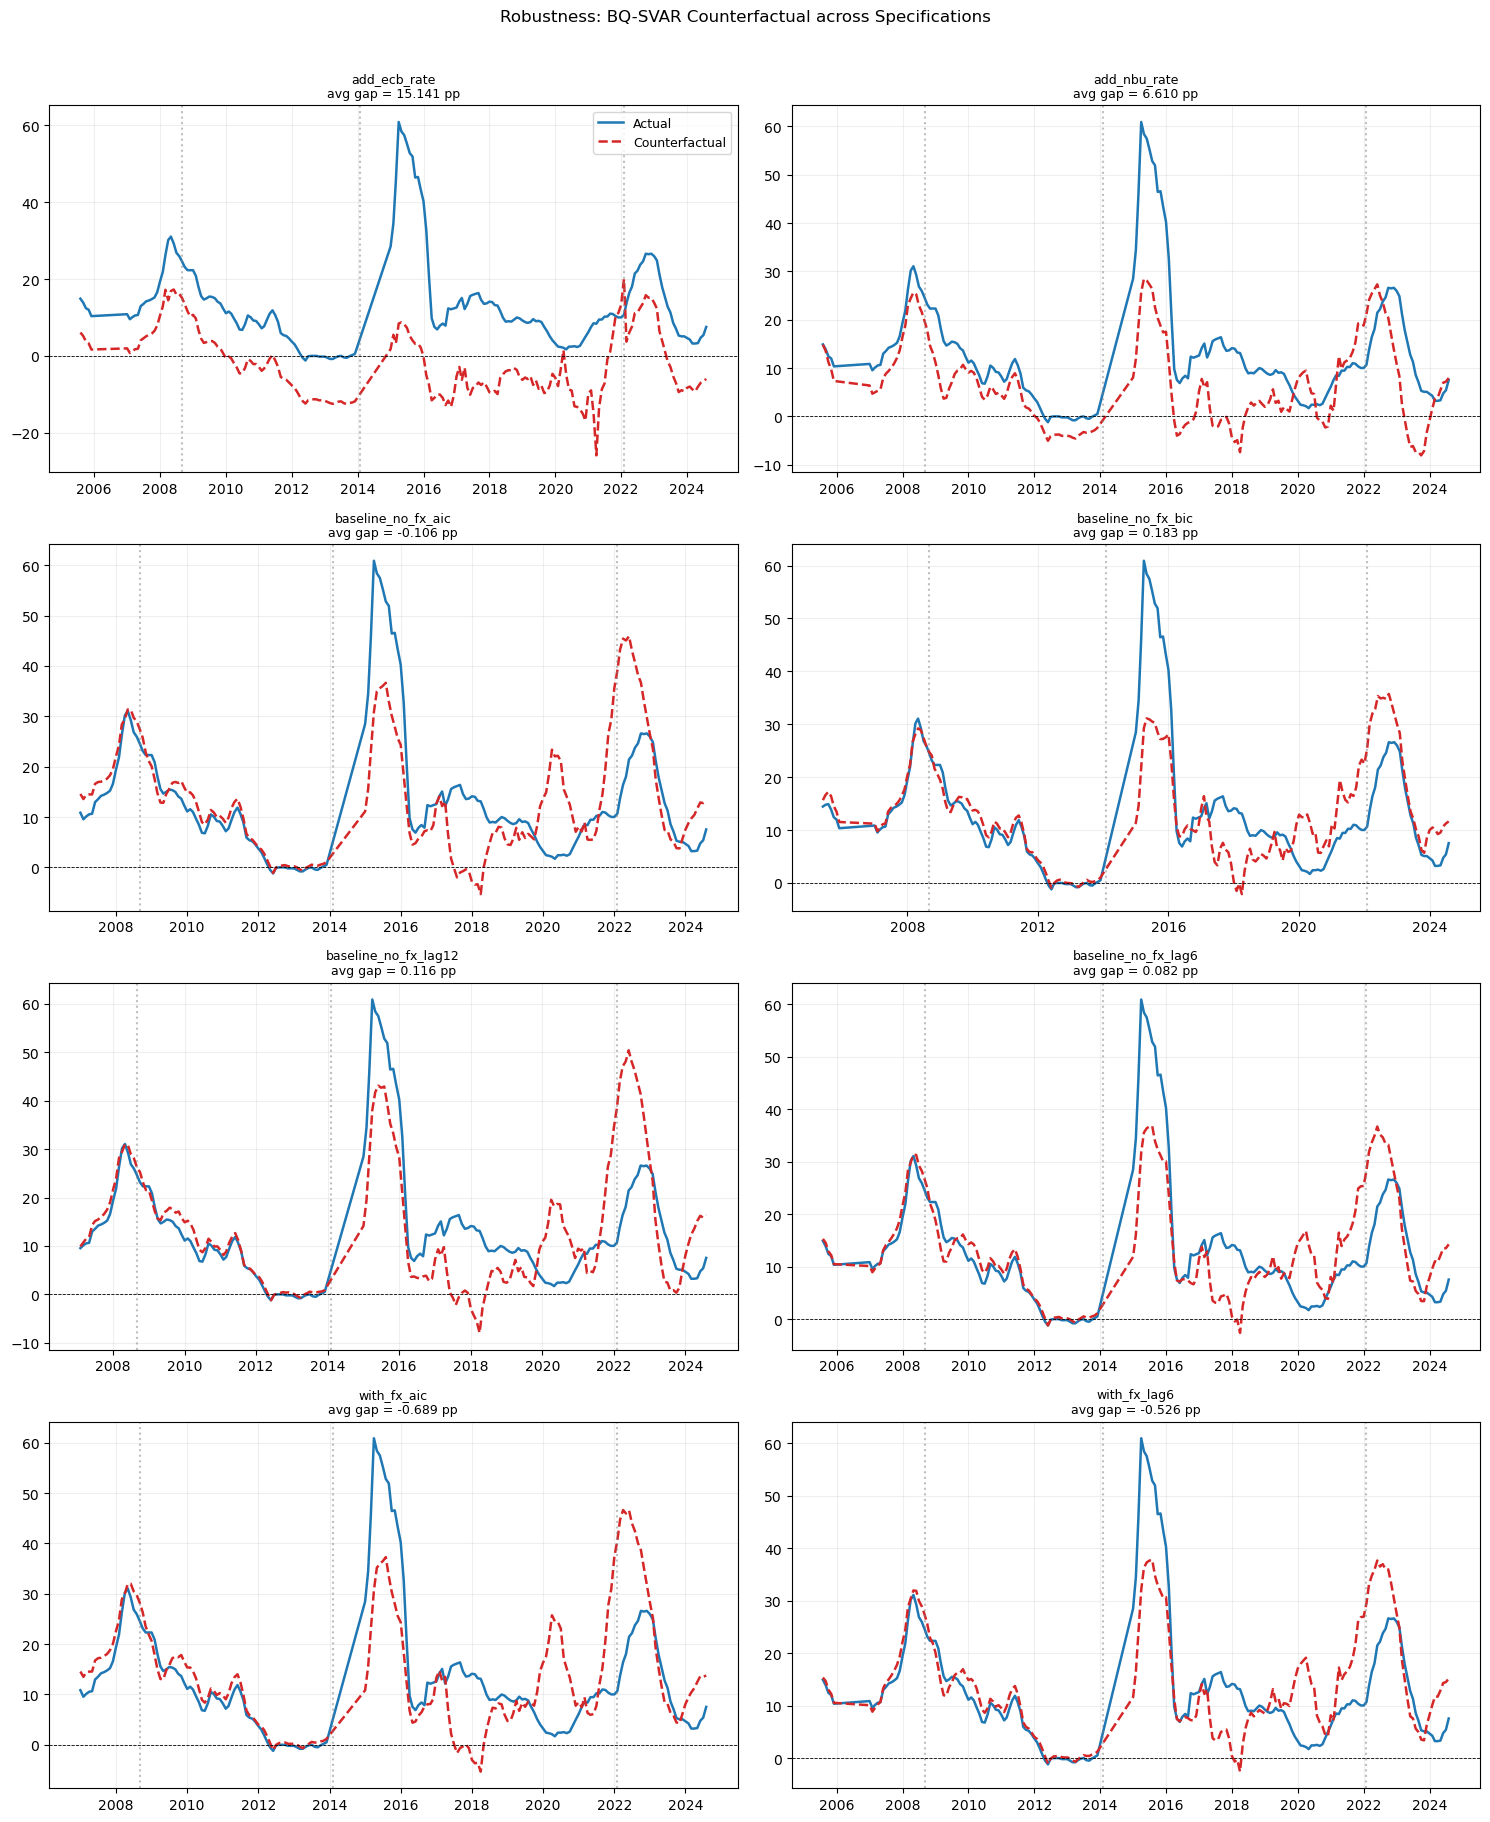


ROBUSTNESS SUMMARY
                spec  n_obs  lag_ukr  lag_ea  avg_actual    avg_cf   avg_gap
        add_ecb_rate    205        6       6   13.019204 -2.121618 15.140822
        add_nbu_rate    205        6       6   13.019204  6.409589  6.609615
  baseline_no_fx_aic    200        5      11   13.026981 13.133219 -0.106238
  baseline_no_fx_bic    207        2       4   13.034598 12.851135  0.183463
baseline_no_fx_lag12    199       12      12   13.037907 12.922168  0.115739
 baseline_no_fx_lag6    205        6       6   13.019204 12.937160  0.082043
         with_fx_aic    200        5      11   13.026981 13.716074 -0.689094
        with_fx_lag6    205        6       6   13.019204 13.545695 -0.526491

CRISIS PEAK COMPARISON ACROSS SPECIFICATIONS
                spec    window  actual_peak   cf_peak        gap
  baseline_no_fx_aic 2008_2009    31.063277 31.358447  -0.295170
  baseline_no_fx_aic 2014_2015    60.905675 36.657262  24.248413
  baseline_no_fx_aic 2022_2023    26.603244 45

In [ ]:
# =============================================================================
# Robustness checks
# Runs the same BQ counterfactual across 8 specifications with varying lag selection methods and exogenous variable sets
# =============================================================================
from model_utils import (
    choose_lag,
    bq_impact_matrix,
    get_structural_shocks,
    simulate_counterfactual,
    crisis_peak,
)


PATH_IN     = OUT_DIR / "bq_svar_inputs.csv"
OUT_SUMMARY = OUT_DIR / "robustness_summary.csv"
OUT_SERIES  = OUT_DIR / "robustness_all_series.csv"
OUT_PEAKS   = OUT_DIR / "robustness_peaks.csv"
OUT_FIG     = OUT_DIR / "robustness_counterfactual_grid.png"

if not PATH_IN.exists():
    raise FileNotFoundError(
        f"Missing input file: {PATH_IN}. Run the dataset-building cell first."
    )

UKR_ENDOG = ["UKR_IP_YOY", "UKR_CPI_YOY"]
EA_ENDOG  = ["EA_IP_YOY",  "EA_HICP_YOY"]

CRISIS_WINDOWS = {
    "2008_2009": ("2008-01-01", "2009-12-01"),
    "2014_2015": ("2014-01-01", "2015-12-01"),
    "2022_2023": ("2022-01-01", "2023-12-01"),
}


def run_spec(spec_name, df, exog_cols, lag_mode, lag_value=None, maxlags=12, ic="aic"):
    needed  = UKR_ENDOG + EA_ENDOG + exog_cols
    est_df  = (df[["date"] + needed]
               .replace([np.inf, -np.inf], np.nan)
               .dropna()
               .drop_duplicates(subset="date")
               .set_index("date")
               .sort_index())
    if len(est_df) < 60:
        raise ValueError(f"{spec_name}: sample too short ({len(est_df)} rows).")

    ukr_e = est_df[UKR_ENDOG].copy()
    ea_e  = est_df[EA_ENDOG].copy()
    exog  = est_df[exog_cols].copy() if exog_cols else None

    if lag_mode == "ic":
        p_ukr = choose_lag(ukr_e, exog, maxlags, ic)
        p_ea  = choose_lag(ea_e,  exog, maxlags, ic)
    else:
        p_ukr = p_ea = int(lag_value)

    ukr_res = VAR(ukr_e, exog=exog).fit(maxlags=p_ukr, trend="c")
    ea_res  = VAR(ea_e,  exog=exog).fit(maxlags=p_ea,  trend="c")

    B_ukr      = bq_impact_matrix(ukr_res.coefs, ukr_res.sigma_u.values)
    B_ea       = bq_impact_matrix(ea_res.coefs,  ea_res.sigma_u.values)
    ea_shocks  = get_structural_shocks(ea_res.resid, B_ea)

    y_cf_df    = simulate_counterfactual(ukr_res, B_ukr, ea_shocks, UKR_ENDOG)
    common_idx = y_cf_df.index.intersection(
        pd.to_datetime(ukr_res.fittedvalues.index).drop_duplicates())
    y_actual   = est_df.loc[common_idx, UKR_ENDOG]
    y_cf_df    = y_cf_df.loc[common_idx]

    out = pd.DataFrame({
        "date":  y_actual.index,
        "spec":  spec_name,
        "ukr_cpi_yoy_actual":         y_actual["UKR_CPI_YOY"].values,
        "ukr_cpi_yoy_counterfactual": y_cf_df["UKR_CPI_YOY"].values,
        "ukr_ip_yoy_actual":          y_actual["UKR_IP_YOY"].values,
        "ukr_ip_yoy_counterfactual":  y_cf_df["UKR_IP_YOY"].values,
    })
    out["inflation_gap"] = out["ukr_cpi_yoy_actual"] - out["ukr_cpi_yoy_counterfactual"]

    summary = {
        "spec": spec_name, "n_obs": len(out),
        "lag_ukr": p_ukr, "lag_ea": p_ea,
        "exog_cols": ", ".join(exog_cols) if exog_cols else "(none)",
        "sample_start": out["date"].min(), "sample_end": out["date"].max(),
        "avg_actual": out["ukr_cpi_yoy_actual"].mean(),
        "avg_cf":     out["ukr_cpi_yoy_counterfactual"].mean(),
        "avg_gap":    out["inflation_gap"].mean(),
    }
    peaks = []
    for lbl, (s, e) in CRISIS_WINDOWS.items():
        ap = crisis_peak(out, s, e, "ukr_cpi_yoy_actual")
        cp = crisis_peak(out, s, e, "ukr_cpi_yoy_counterfactual")
        peaks.append({"spec": spec_name, "window": lbl,
                      "actual_peak": ap, "cf_peak": cp,
                      "gap": ap - cp if pd.notna(ap) and pd.notna(cp) else np.nan})
    return summary, out, pd.DataFrame(peaks)

# ── Specification grid ───
# The spec baseline uses no FX to be conceptually clean for the counterfactual, since EA membership would remove the FX channel.
# The "with_fx" spec adds dlog_uah_usd as a robustness comparison only so it shows what changes when we condition on the FX channel that EA membership would remove.

SPECS = [
    dict(spec_name="baseline_no_fx_aic",
         exog_cols=["dlog_oil","dlog_wheat"], lag_mode="ic",    ic="aic", lag_value=None,  maxlags=12),
    dict(spec_name="baseline_no_fx_bic",
         exog_cols=["dlog_oil","dlog_wheat"], lag_mode="ic",    ic="bic", lag_value=None,  maxlags=12),
    dict(spec_name="baseline_no_fx_lag6",
         exog_cols=["dlog_oil","dlog_wheat"], lag_mode="fixed", ic="aic", lag_value=6,     maxlags=12),
    dict(spec_name="baseline_no_fx_lag12",
         exog_cols=["dlog_oil","dlog_wheat"], lag_mode="fixed", ic="aic", lag_value=12,    maxlags=12),
    dict(spec_name="with_fx_aic",
         exog_cols=["dlog_uah_usd","dlog_oil","dlog_wheat"], lag_mode="ic",    ic="aic", lag_value=None, maxlags=12),
    dict(spec_name="with_fx_lag6",
         exog_cols=["dlog_uah_usd","dlog_oil","dlog_wheat"], lag_mode="fixed", ic="aic", lag_value=6,    maxlags=12),
    dict(spec_name="add_nbu_rate",
         exog_cols=["dlog_oil","dlog_wheat","NBU_POLICY_RATE"], lag_mode="fixed", ic="aic", lag_value=6, maxlags=12),
    dict(spec_name="add_ecb_rate",
         exog_cols=["dlog_oil","dlog_wheat","ECB_REFI_RATE"],   lag_mode="fixed", ic="aic", lag_value=6, maxlags=12),
]

df = pd.read_csv(PATH_IN, parse_dates=["date"]).sort_values("date").reset_index(drop=True)

all_summaries, all_series, all_peaks = [], [], []
print("=" * 70)
print("ROBUSTNESS CHECKS")
print("=" * 70)
for spec in SPECS:
    name = spec["spec_name"]
    try:
        s, ser, pk = run_spec(**spec, df=df)
        all_summaries.append(s); all_series.append(ser); all_peaks.append(pk)
        print(f"  OK  {name:<30}  n={s['n_obs']}  gap={s['avg_gap']:.3f} pp")
    except Exception as e:
        print(f"  ERR {name:<30}  {e}")

summary_df = pd.DataFrame(all_summaries)
if not summary_df.empty and "spec" in summary_df.columns:
    summary_df = summary_df.sort_values("spec").reset_index(drop=True)

series_df = pd.concat(all_series, ignore_index=True) if all_series else pd.DataFrame()
peaks_df  = pd.concat(all_peaks, ignore_index=True) if all_peaks else pd.DataFrame()

if summary_df.empty:
    print("\nNo specifications completed successfully.")
    print("Look at the ERR lines printed above — that is the real error.")


summary_df.to_csv(OUT_SUMMARY, index=False)
series_df.to_csv(OUT_SERIES, index=False)
peaks_df.to_csv(OUT_PEAKS, index=False)

# ── Robustness plot grid ──
if not series_df.empty:
    specs_ok = summary_df["spec"].tolist()
    n = len(specs_ok); ncols = 2; nrows = -(-n // ncols)  # ceiling div
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.5 * nrows), sharex=False)
    axes = np.array(axes).reshape(-1)
    for i, sn in enumerate(specs_ok):
        ax  = axes[i]
        sub = series_df[series_df["spec"] == sn]
        ax.plot(sub["date"], sub["ukr_cpi_yoy_actual"],
                label="Actual" if i == 0 else "", lw=1.8, color="#1f77b4")
        ax.plot(sub["date"], sub["ukr_cpi_yoy_counterfactual"],
                label="Counterfactual" if i == 0 else "",
                lw=1.8, ls="--", color="#d62728")
        for d in ["2008-09-01","2014-02-01","2022-02-01"]:
            ax.axvline(pd.Timestamp(d), color="grey", ls=":", alpha=0.5)
        ax.axhline(0, color="black", ls="--", lw=0.6)
        gap = summary_df.loc[summary_df["spec"]==sn, "avg_gap"].iloc[0]
        ax.set_title(f"{sn}\navg gap = {gap:.3f} pp", fontsize=9)
        ax.grid(alpha=0.2)
        if i == 0:
            ax.legend(fontsize=9)
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")
    plt.suptitle("Robustness: BQ-SVAR Counterfactual across Specifications",
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(OUT_FIG, dpi=150, bbox_inches="tight")
    plt.show()

# ── Print tables ───
print("\n" + "=" * 70)
print("ROBUSTNESS SUMMARY")
print("=" * 70)
show = ["spec","n_obs","lag_ukr","lag_ea","avg_actual","avg_cf","avg_gap"]
if not summary_df.empty:
    print(summary_df[[c for c in show if c in summary_df.columns]].to_string(index=False))
else:
    print("No successful specifications.")

print("\n" + "=" * 70)
print("CRISIS PEAK COMPARISON ACROSS SPECIFICATIONS")
print("=" * 70)
if not peaks_df.empty:
    print(peaks_df.to_string(index=False))
else:
    print("No peak comparisons available.")
    
print("\nSaved:", OUT_SUMMARY, OUT_SERIES, OUT_PEAKS, OUT_FIG, sep="\n  ")
